<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day15_selestkbest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SelectKBest (Statistical Test)
SelectKBest is a filter-based feature selection technique from scikit-learn.

It selects the top K most important features based on a scoring function.

Unlike correlation filtering (feature vs feature), SelectKBest checks Feature vs Target relationship



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression

#car dataset

data ={
    "Engine_size":[1.2,1.5,2.0,2.2,3.0,3.5,4.0,1.8,2.5,3.2],
    "Horsepower": [90,110,150,170,220,250,300,140,200,240],
    "Weight": [900,1000,1300,1500,1800,2000,2200,1250,1700,1950],
    "Fuel_Consumption":[15,14,12,11,9,8,7,13,10,8.5],
    "Mileage":[20,19,16,15,12,11,10,17,13,11],
    "Price": [8000,10000,15000,17000,25000,28000,35000,13000,22000,30000]

}

df = pd.DataFrame(data)

X = df.drop("Price",axis=1)
y = df["Price"]
print("Original Features:",list(X.columns))

#Apply Selectkbest

selector = SelectKBest(score_func=f_regression,k=3) # f_regression measures linear relationship with target
X_new = selector.fit_transform(X,y)

print("\n F-Scores:")
for feature,score in zip(X.columns,selector.scores_):

  print( feature,":",score)

#get selected feature names
selected_features = X.columns[selector.get_support()]
print("\n selected Features:",list(selected_features))





Original Features: ['Engine_size', 'Horsepower', 'Weight', 'Fuel_Consumption', 'Mileage']

 F-Scores:
Engine_size : 358.9855601714234
Horsepower : 578.8028185670616
Weight : 350.00313596038825
Fuel_Consumption : 231.07741738066323
Mileage : 186.81008559950146

 selected Features: ['Engine_size', 'Horsepower', 'Weight']


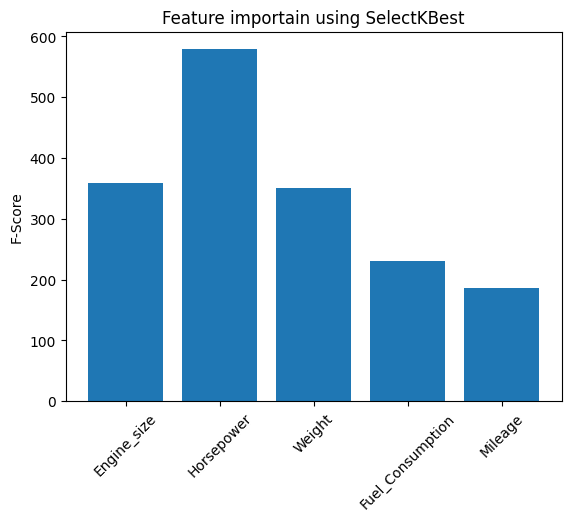

In [7]:
#Visualization of Scores

scores = selector.scores_

plt.figure()
plt.bar(X.columns,scores)
plt.xticks(rotation=45)
plt.title("Feature importain using SelectKBest")
plt.ylabel("F-Score")
plt.show()

Recursive Feature Elimination (RFE)

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [9]:
X, y = make_classification(n_samples=100, n_features=10, random_state=42)

model = LogisticRegression(max_iter=1000) #Logistic regression estimates feature importance
rfe = RFE(model, n_features_to_select=5) #Recursively removes least important features

X_rfe = rfe.fit_transform(X, y)
print(X_rfe.shape)

'''
Trains model multiple times
Eliminates weakest features step-by-step
Smart selection using ML model itself
'''

(100, 5)


'\nTrains model multiple times\nEliminates weakest features step-by-step\nSmart selection using ML model itself\n'

Feature Extraction

Polynomial Feature Extraction

It creates new features by combining existing features using powers and multiplications.
It essentially creates all combinations of features up to a certain degree.
Double-click (or enter) to edit

converts [x1, x2] → [x1, x2, x1², x1x2, x2²]

In [14]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.array([[1,2],[3,4],[5,6]]) # Original Features : x1 and x2

poly = PolynomialFeatures(degree=3, include_bias=False ) #Generates polynomial combination up to degree 2
X_poly = poly.fit_transform(X)

print(X_poly)
#used to model non_linear relationship


[[  1.   2.   1.   2.   4.   1.   2.   4.   8.]
 [  3.   4.   9.  12.  16.  27.  36.  48.  64.]
 [  5.   6.  25.  30.  36. 125. 150. 180. 216.]]


Text Feature Extraction (TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "machine learning is powerful",
    "deep learning uses neural networks",
    "machine learning and deep learning"
]

vectorizer = TfidfVectorizer() # convert text to numerical features
X_tfidf= vectorizer.fit_transform(documents)

print(X_tfidf.toarray())
'''
Learns vocabulary
Computes TF-IDF score for each word

TF-IDF meaning:
High value → important word
Low value → common word
'''

[[0.         0.         0.5844829  0.34520502 0.44451431 0.
  0.         0.5844829  0.        ]
 [0.         0.38376993 0.         0.29803159 0.         0.50461134
  0.50461134 0.         0.50461134]
 [0.53058735 0.40352536 0.         0.62674687 0.40352536 0.
  0.         0.         0.        ]]


'\nLearns vocabulary\nComputes TF-IDF score for each word\n\nTF-IDF meaning:\nHigh value → important word\nLow value → common word\n'

Converts text to numerical features.

Image Feature extraction Flattening

In [16]:
import numpy as np

# 28*28 grayscale image
image= np.random.rand(28,28)

#Convert 2D image -> 1D feature vector
flattened = image.reshape(-1)
print(flattened.shape)

(784,)
